In [26]:
import sys
print(sys.executable)

c:\Users\shubh\AppData\Local\Programs\Python\Python312\python.exe


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("../data/Base.csv")
print(df.shape)
print(df.head())
print(df.info())
print(df.describe)

(1000000, 32)
   fraud_bool  income  name_email_similarity  prev_address_months_count  \
0           0     0.3               0.986506                         -1   
1           0     0.8               0.617426                         -1   
2           0     0.8               0.996707                          9   
3           0     0.6               0.475100                         11   
4           0     0.9               0.842307                         -1   

   current_address_months_count  customer_age  days_since_request  \
0                            25            40            0.006735   
1                            89            20            0.010095   
2                            14            40            0.012316   
3                            14            30            0.006991   
4                            29            40            5.742626   

   intended_balcon_amount payment_type  zip_count_4w  ...  has_other_cards  \
0              102.453711           AA    

,Missing Values,Percentage
fraud_bool,0,0.0
income,0,0.0
name_email_similarity,0,0.0
prev_address_months_count,0,0.0
current_address_months_count,0,0.0
customer_age,0,0.0
days_since_request,0,0.0
intended_balcon_amount,0,0.0
payment_type,0,0.0
zip_count_4w,0,0.0


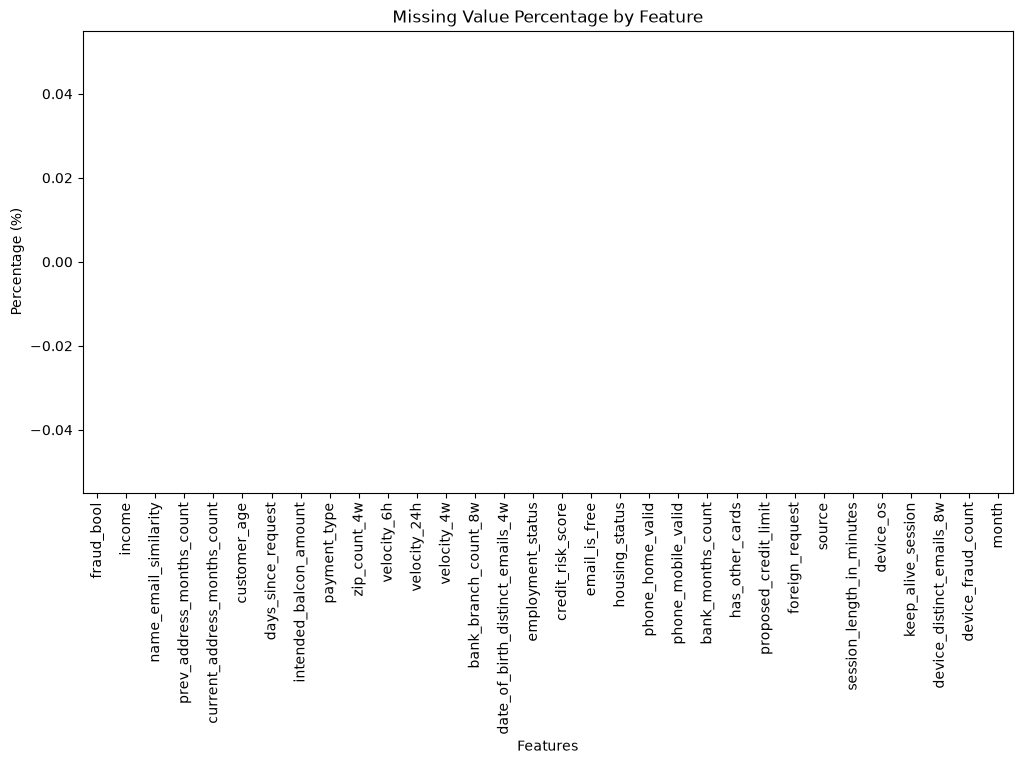

In [3]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df)) * 100
})

missing_df = missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_df)

plt.figure(figsize=(12, 6))

missing_df["Percentage"].plot(kind="bar")

plt.title("Missing Value Percentage by Feature")
plt.ylabel("Percentage (%)")
plt.xlabel("Features")
plt.xticks(rotation=90)

plt.show()

In [4]:
target_col = "fraud_bool"

numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

# Remove target from numerical features
numerical_features = [
    col for col in numerical_cols
    if col != target_col
]

print("Numerical Features:", len(numerical_features))
print(numerical_features)

print("\nCategorical Features:", len(categorical_cols))
print(categorical_cols)

Numerical Features: 26
['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']

Categorical Features: 5
['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']


In [5]:
class_counts = df["fraud_bool"].value_counts()

print(class_counts)

print("\nClass Percentage:")
print(
    df["fraud_bool"]
    .value_counts(normalize=True)
    * 100
)

fraud_bool
0    988971
1     11029
Name: count, dtype: int64

Class Percentage:
fraud_bool
0    98.8971
1     1.1029
Name: proportion, dtype: float64


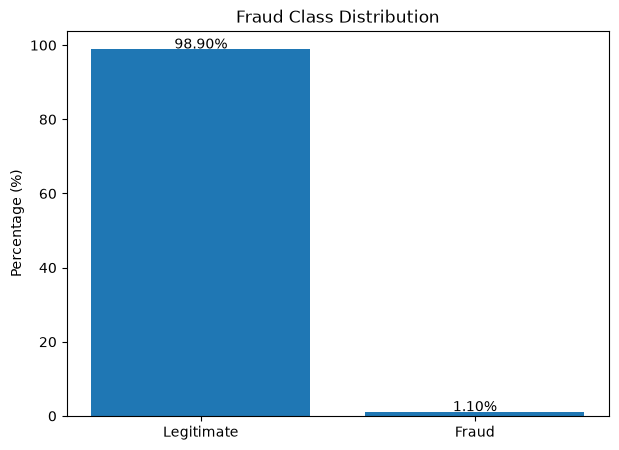

In [6]:
fraud_percentage = (
    df["fraud_bool"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure(figsize=(7, 5))

plt.bar(
    ["Legitimate", "Fraud"],
    fraud_percentage.values
)

plt.ylabel("Percentage (%)")
plt.title("Fraud Class Distribution")

for i, value in enumerate(fraud_percentage.values):
    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [7]:
legitimate = (df["fraud_bool"] == 0).sum()
fraud = (df["fraud_bool"] == 1).sum()

imbalance_ratio = legitimate / fraud

print(f"Legitimate transactions: {legitimate:,}")
print(f"Fraud transactions: {fraud:,}")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")

Legitimate transactions: 988,971
Fraud transactions: 11,029
Imbalance Ratio: 89.67:1


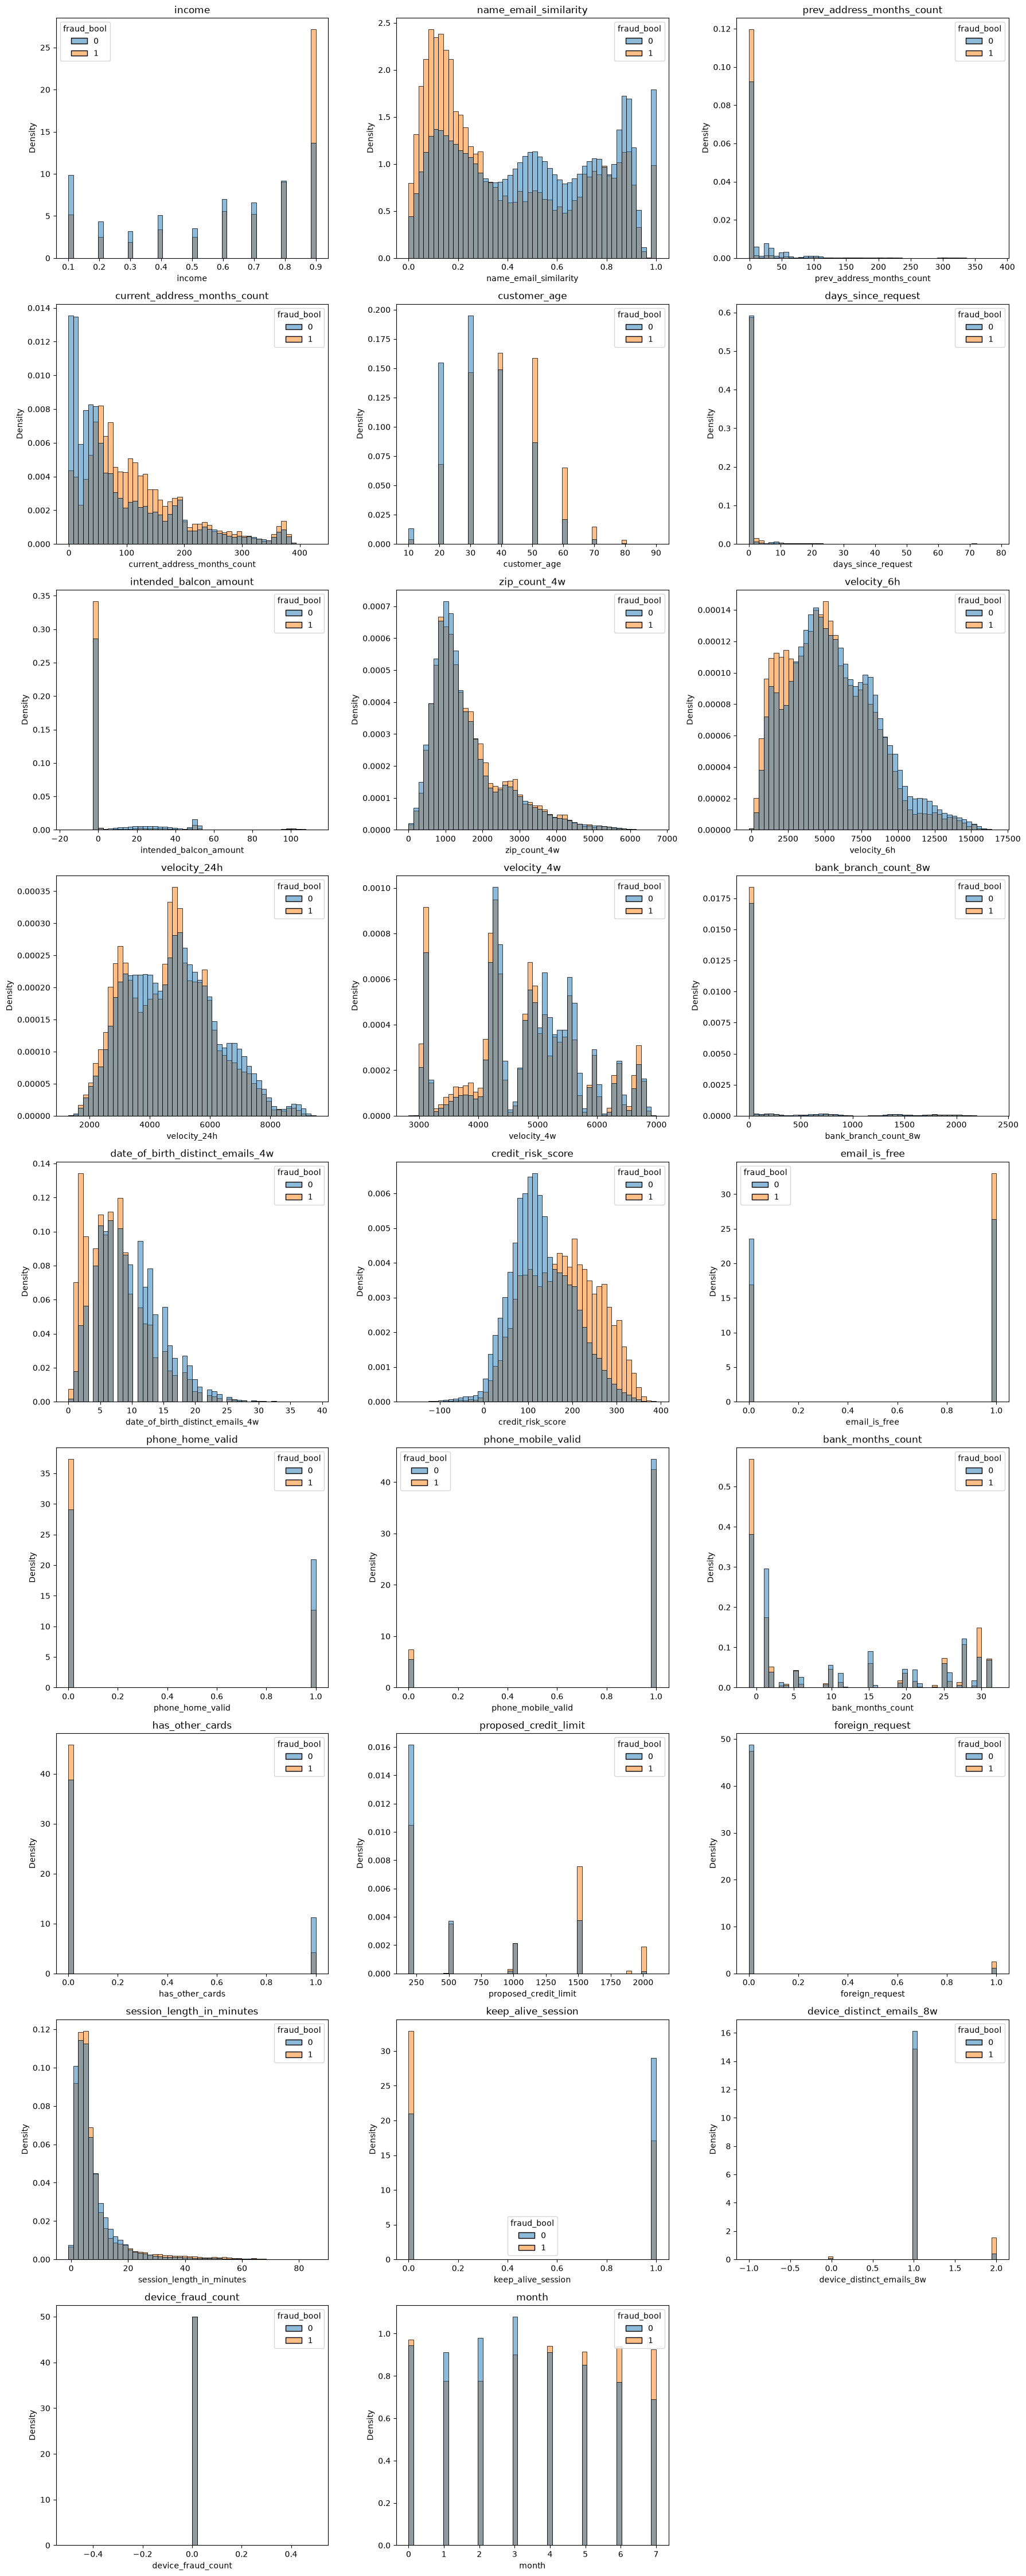

In [8]:
num_cols = numerical_features

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.histplot(
        data=df,
        x=col,
        hue="fraud_bool",
        bins=50,
        kde=False,
        stat="density",
        common_norm=False,
        ax=axes[i]
    )

    axes[i].set_title(col)

# Remove unused plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

<Axes: xlabel='month', ylabel='Count'>

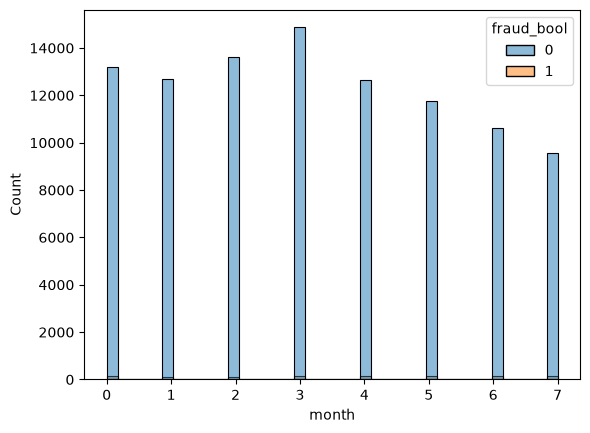

In [10]:
df_sample = df.sample(
    n=100000,
    random_state=42
)
sns.histplot(
    data=df_sample,
    x=col,
    hue="fraud_bool"
)


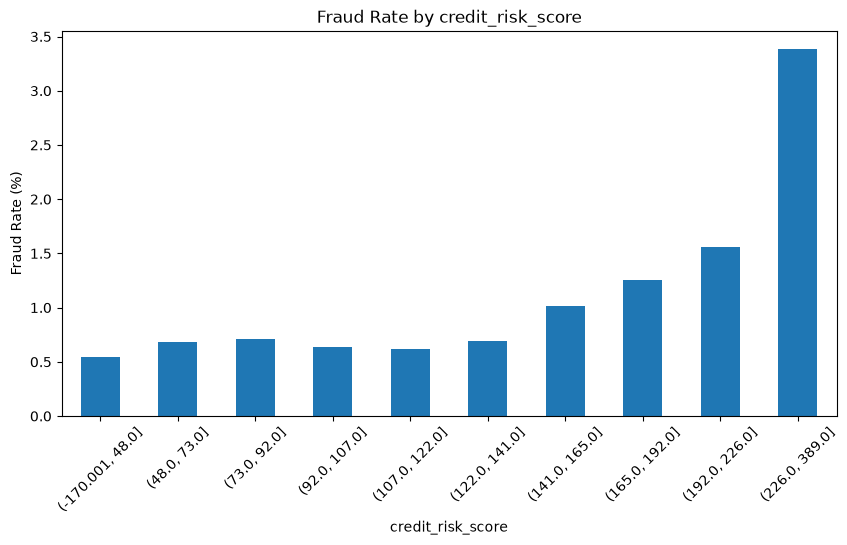

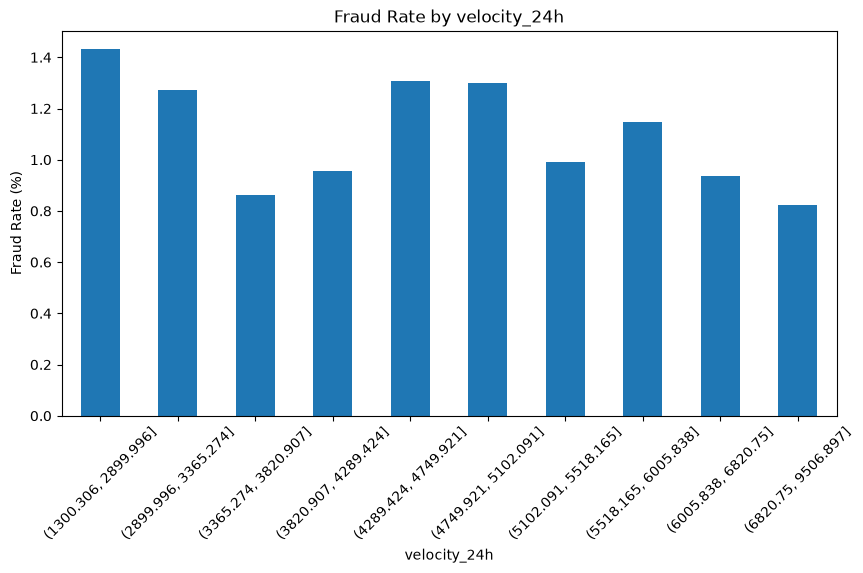

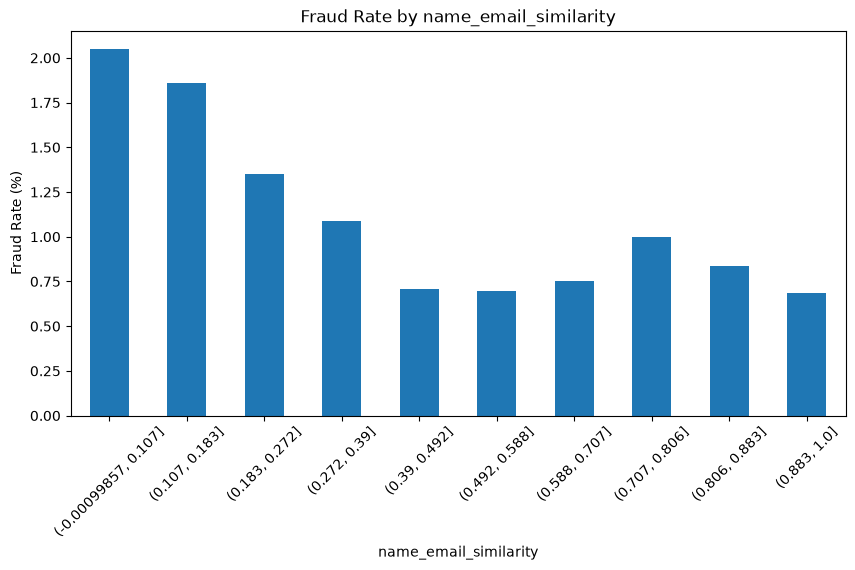

In [12]:
# fraud rate for numerical features
def plot_fraud_rate_by_bins(df, column, bins=10):

    temp = df[[column, "fraud_bool"]].copy()

    temp["bin"] = pd.qcut(
        temp[column],
        q=bins,
        duplicates="drop"
    )

    fraud_rate = (
        temp.groupby("bin", observed=True)["fraud_bool"]
        .mean()
        * 100
    )

    plt.figure(figsize=(10, 5))

    fraud_rate.plot(
        kind="bar"
    )

    plt.title(
        f"Fraud Rate by {column}"
    )

    plt.ylabel("Fraud Rate (%)")
    plt.xlabel(column)

    plt.xticks(rotation=45)

    plt.show()


plot_fraud_rate_by_bins(
    df,
    "credit_risk_score"
)

plot_fraud_rate_by_bins(
    df,
    "velocity_24h"
)

plot_fraud_rate_by_bins(
    df,
    "name_email_similarity"
)


Feature: payment_type
payment_type
AB    370554
AA    258249
AC    252071
AD    118837
AE       289
Name: count, dtype: int64


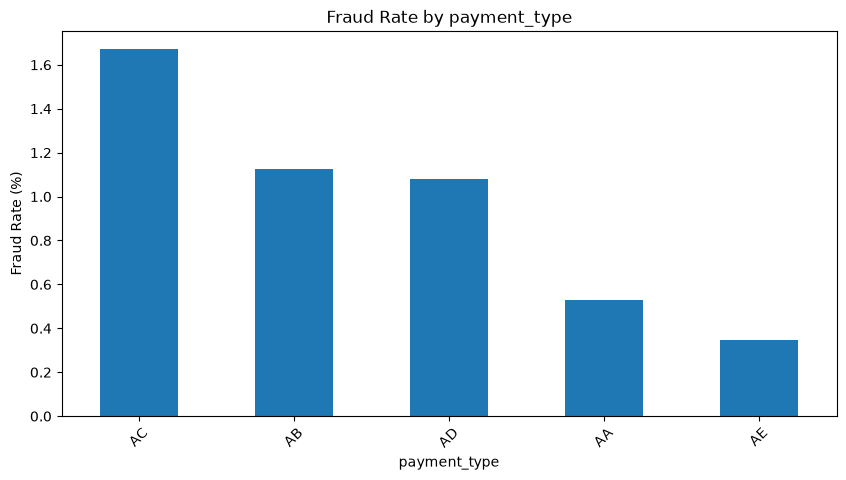


Feature: employment_status
employment_status
CA    730252
CB    138288
CF     44034
CC     37758
CD     26522
CE     22693
CG       453
Name: count, dtype: int64


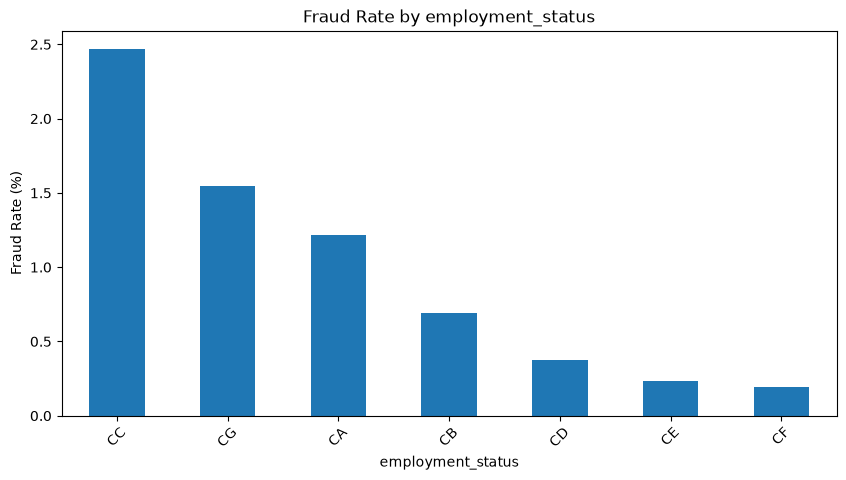


Feature: housing_status
housing_status
BC    372143
BB    260965
BA    169675
BE    169135
BD     26161
BF      1669
BG       252
Name: count, dtype: int64


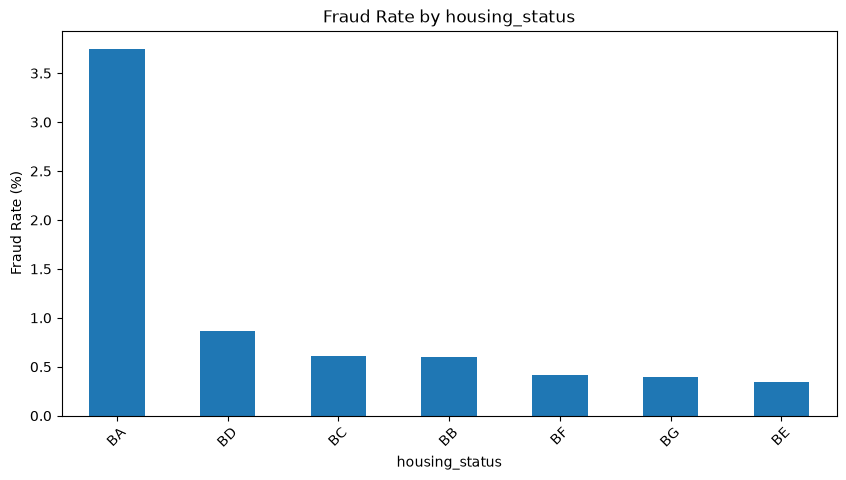


Feature: source
source
INTERNET    992952
TELEAPP       7048
Name: count, dtype: int64


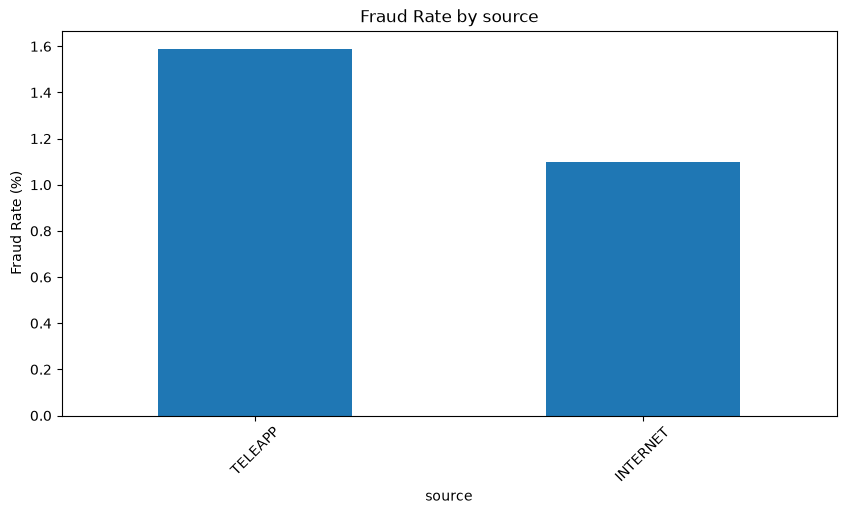


Feature: device_os
device_os
other        342728
linux        332712
windows      263506
macintosh     53826
x11            7228
Name: count, dtype: int64


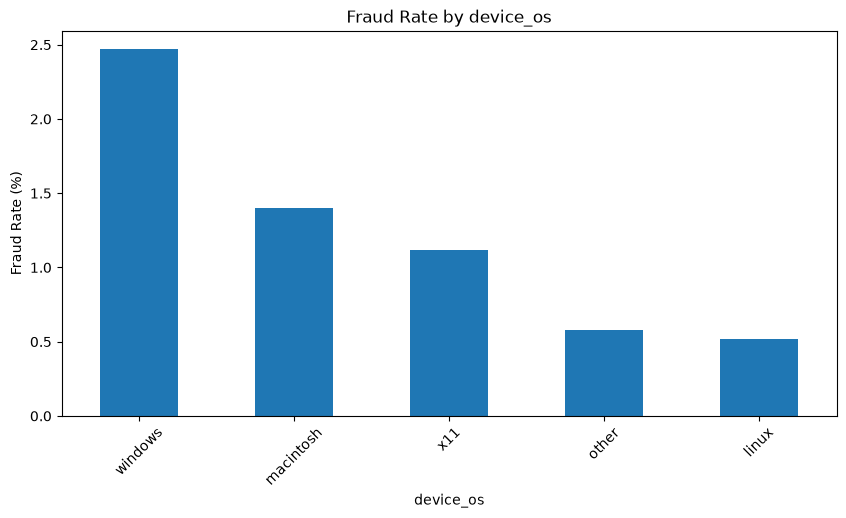

In [13]:
# categorical features analysis
for col in categorical_cols:

    print(f"\n{'='*50}")
    print(f"Feature: {col}")
    print(df[col].value_counts())

    fraud_rate = (
        df.groupby(col)["fraud_bool"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    plt.figure(figsize=(10, 5))

    fraud_rate.plot(
        kind="bar"
    )

    plt.title(
        f"Fraud Rate by {col}"
    )

    plt.ylabel("Fraud Rate (%)")
    plt.xlabel(col)

    plt.xticks(rotation=45)

    plt.show()

count    1000000.000000
mean          33.689080
std           12.025799
min           10.000000
25%           20.000000
50%           30.000000
75%           40.000000
max           90.000000
Name: customer_age, dtype: float64
customer_age
10     20987
20    245855
30    311433
40    238712
50    140353
60     34770
70      6517
80      1297
90        76
Name: count, dtype: int64


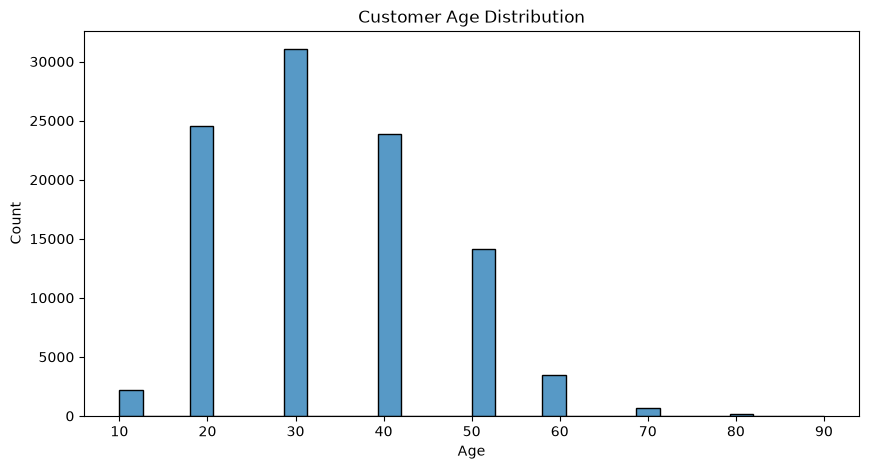

age_group
18-24    266842
25-34    311433
35-44    238712
45-54    140353
55-64     34770
65+        7890
Name: count, dtype: int64


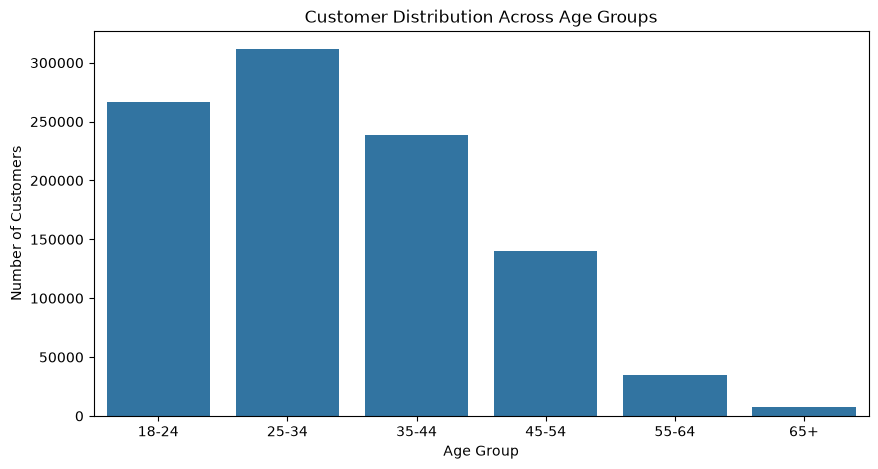

In [14]:
print(df["customer_age"].describe())

print(
    df["customer_age"]
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(10, 5))

sns.histplot(
    df_sample["customer_age"],
    bins=30
)

plt.title("Customer Age Distribution")

plt.xlabel("Age")

plt.show()
def age_group(age):

    if age < 25:
        return "18-24"

    elif age < 35:
        return "25-34"

    elif age < 45:
        return "35-44"

    elif age < 55:
        return "45-54"

    elif age < 65:
        return "55-64"

    else:
        return "65+"

df["age_group"] = df["customer_age"].apply(
    age_group
)
age_distribution = (
    df["age_group"]
    .value_counts()
    .sort_index()
)

print(age_distribution)
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="age_group",
    order=[
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+"
    ]
)

plt.title("Customer Distribution Across Age Groups")

plt.xlabel("Age Group")

plt.ylabel("Number of Customers")

plt.show()

age_group
18-24    0.479310
25-34    0.831318
35-44    1.204799
45-54    1.998532
55-64    3.304573
65+      4.195184
Name: fraud_bool, dtype: float64


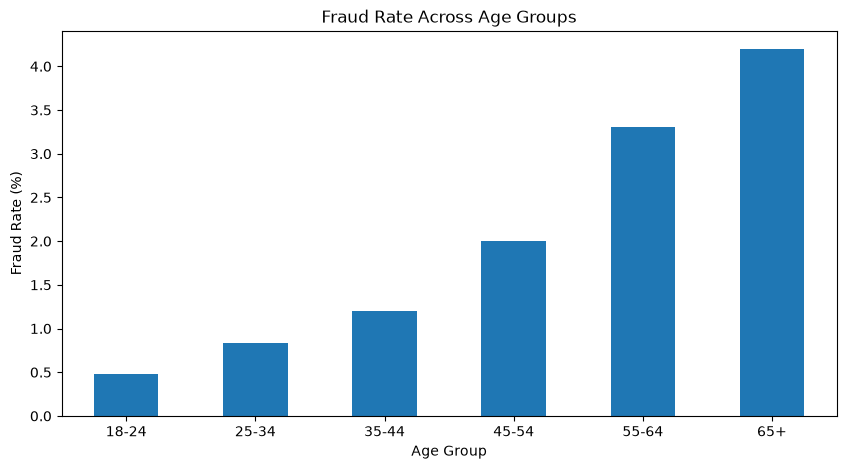

In [16]:
# fraud rate across all groups
age_fraud_rate = (
    df.groupby("age_group")["fraud_bool"]
    .mean()
    * 100
)

age_fraud_rate = age_fraud_rate.reindex([
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
])

print(age_fraud_rate)
plt.figure(figsize=(10, 5))

age_fraud_rate.plot(
    kind="bar"
)

plt.title("Fraud Rate Across Age Groups")

plt.ylabel("Fraud Rate (%)")

plt.xlabel("Age Group")

plt.xticks(rotation=0)

plt.show()

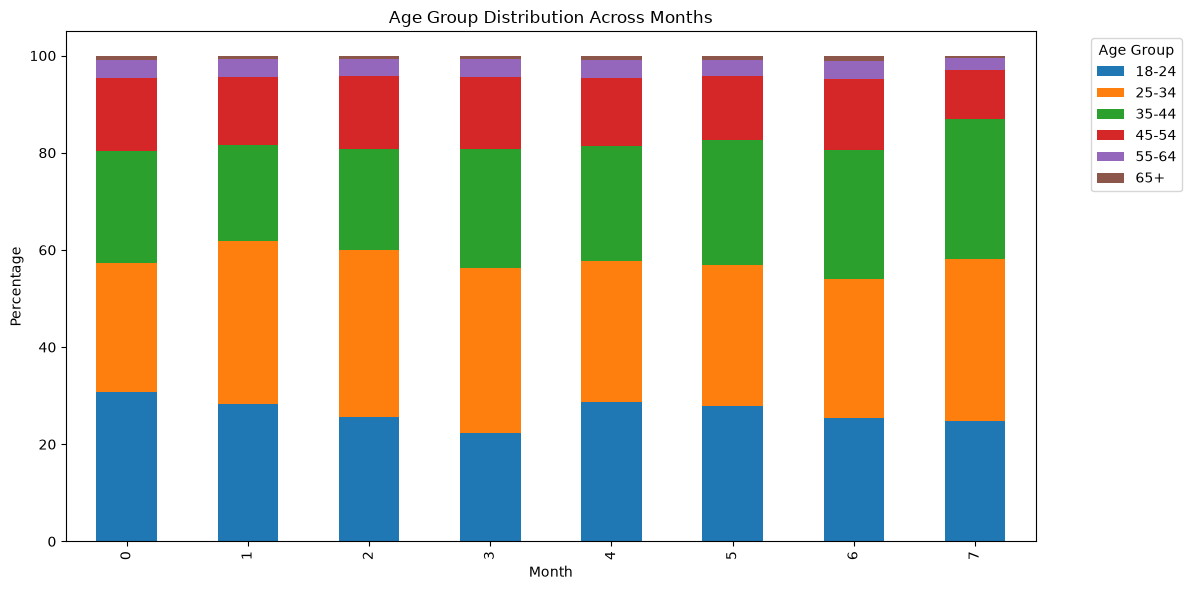

In [17]:
# age distribution across months
age_month = pd.crosstab(
    df["month"],
    df["age_group"],
    normalize="index"
) * 100

age_month.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title(
    "Age Group Distribution Across Months"
)

plt.ylabel("Percentage")

plt.xlabel("Month")

plt.legend(
    title="Age Group",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()

plt.show()

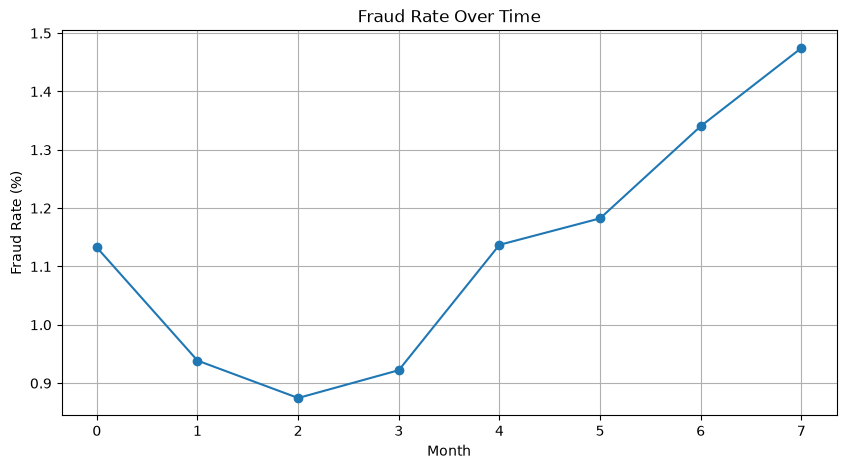

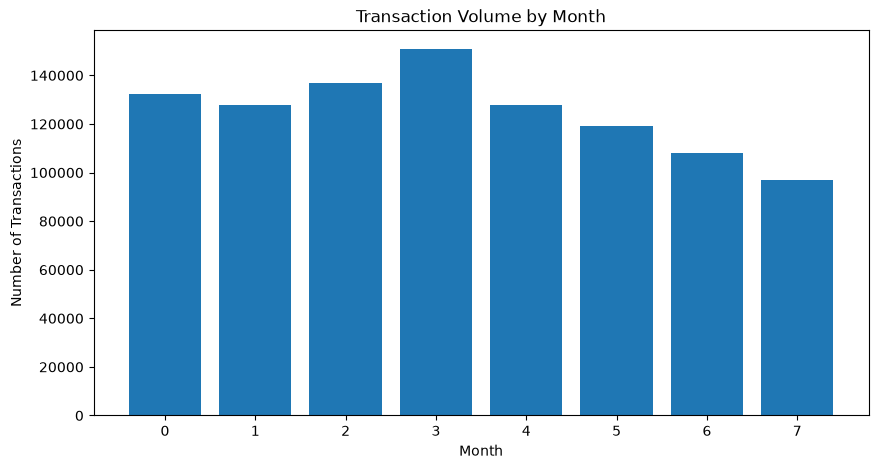

In [18]:
monthly_fraud = (
    df.groupby("month")["fraud_bool"]
    .mean()
    * 100
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_fraud.index,
    monthly_fraud.values,
    marker="o"
)

plt.title("Fraud Rate Over Time")

plt.xlabel("Month")

plt.ylabel("Fraud Rate (%)")

plt.grid()

plt.show()
monthly_volume = df["month"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(
    monthly_volume.index,
    monthly_volume.values
)

plt.title("Transaction Volume by Month")

plt.xlabel("Month")

plt.ylabel("Number of Transactions")

plt.show()

In [19]:
print(
    df["month"]
    .value_counts()
    .sort_index()
)
train_df = df[df["month"] < 5]

val_df = df[
    (df["month"] >= 5) &
    (df["month"] < 6)
]

test_df = df[df["month"] >= 6]

month
0    132440
1    127620
2    136979
3    150936
4    127691
5    119323
6    108168
7     96843
Name: count, dtype: int64


fraud_bool                          1.000000
credit_risk_score                   0.070624
proposed_credit_limit               0.068907
customer_age                        0.062959
income                              0.045079
device_distinct_emails_8w           0.035704
current_address_months_count        0.033701
email_is_free                       0.027758
foreign_request                     0.016885
month                               0.013250
session_length_in_minutes           0.008999
zip_count_4w                        0.005212
days_since_request                  0.000567
bank_months_count                  -0.003222
velocity_24h                       -0.011183
velocity_4w                        -0.011536
bank_branch_count_8w               -0.011577
phone_mobile_valid                 -0.013180
velocity_6h                        -0.016892
intended_balcon_amount             -0.024524
prev_address_months_count          -0.026031
phone_home_valid                   -0.035128
has_other_

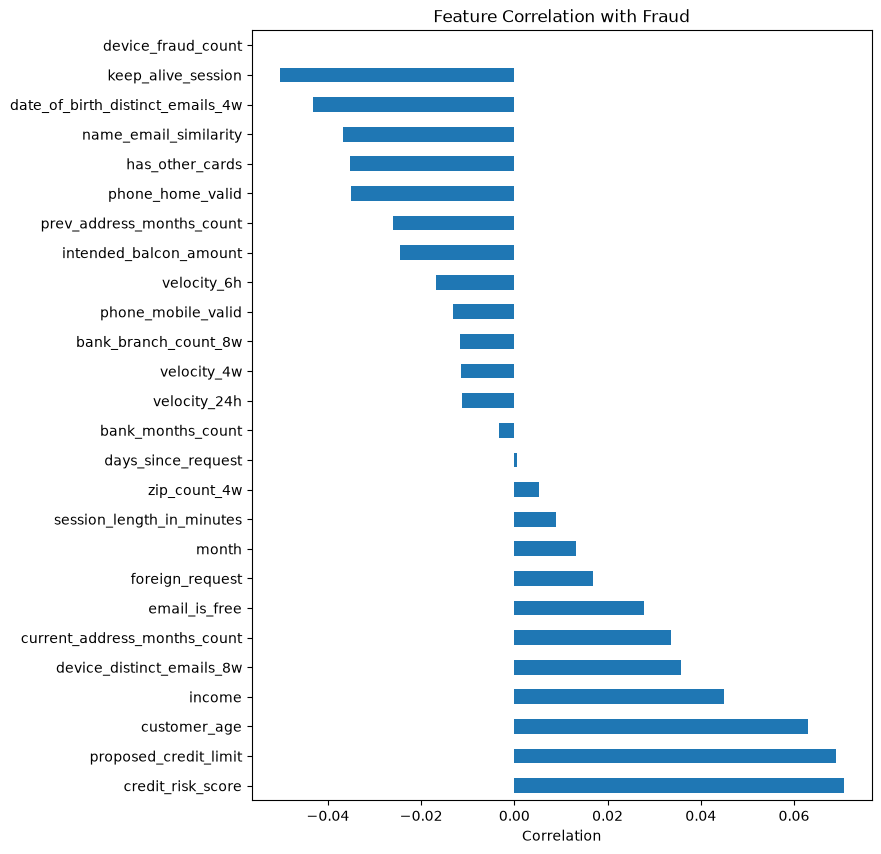

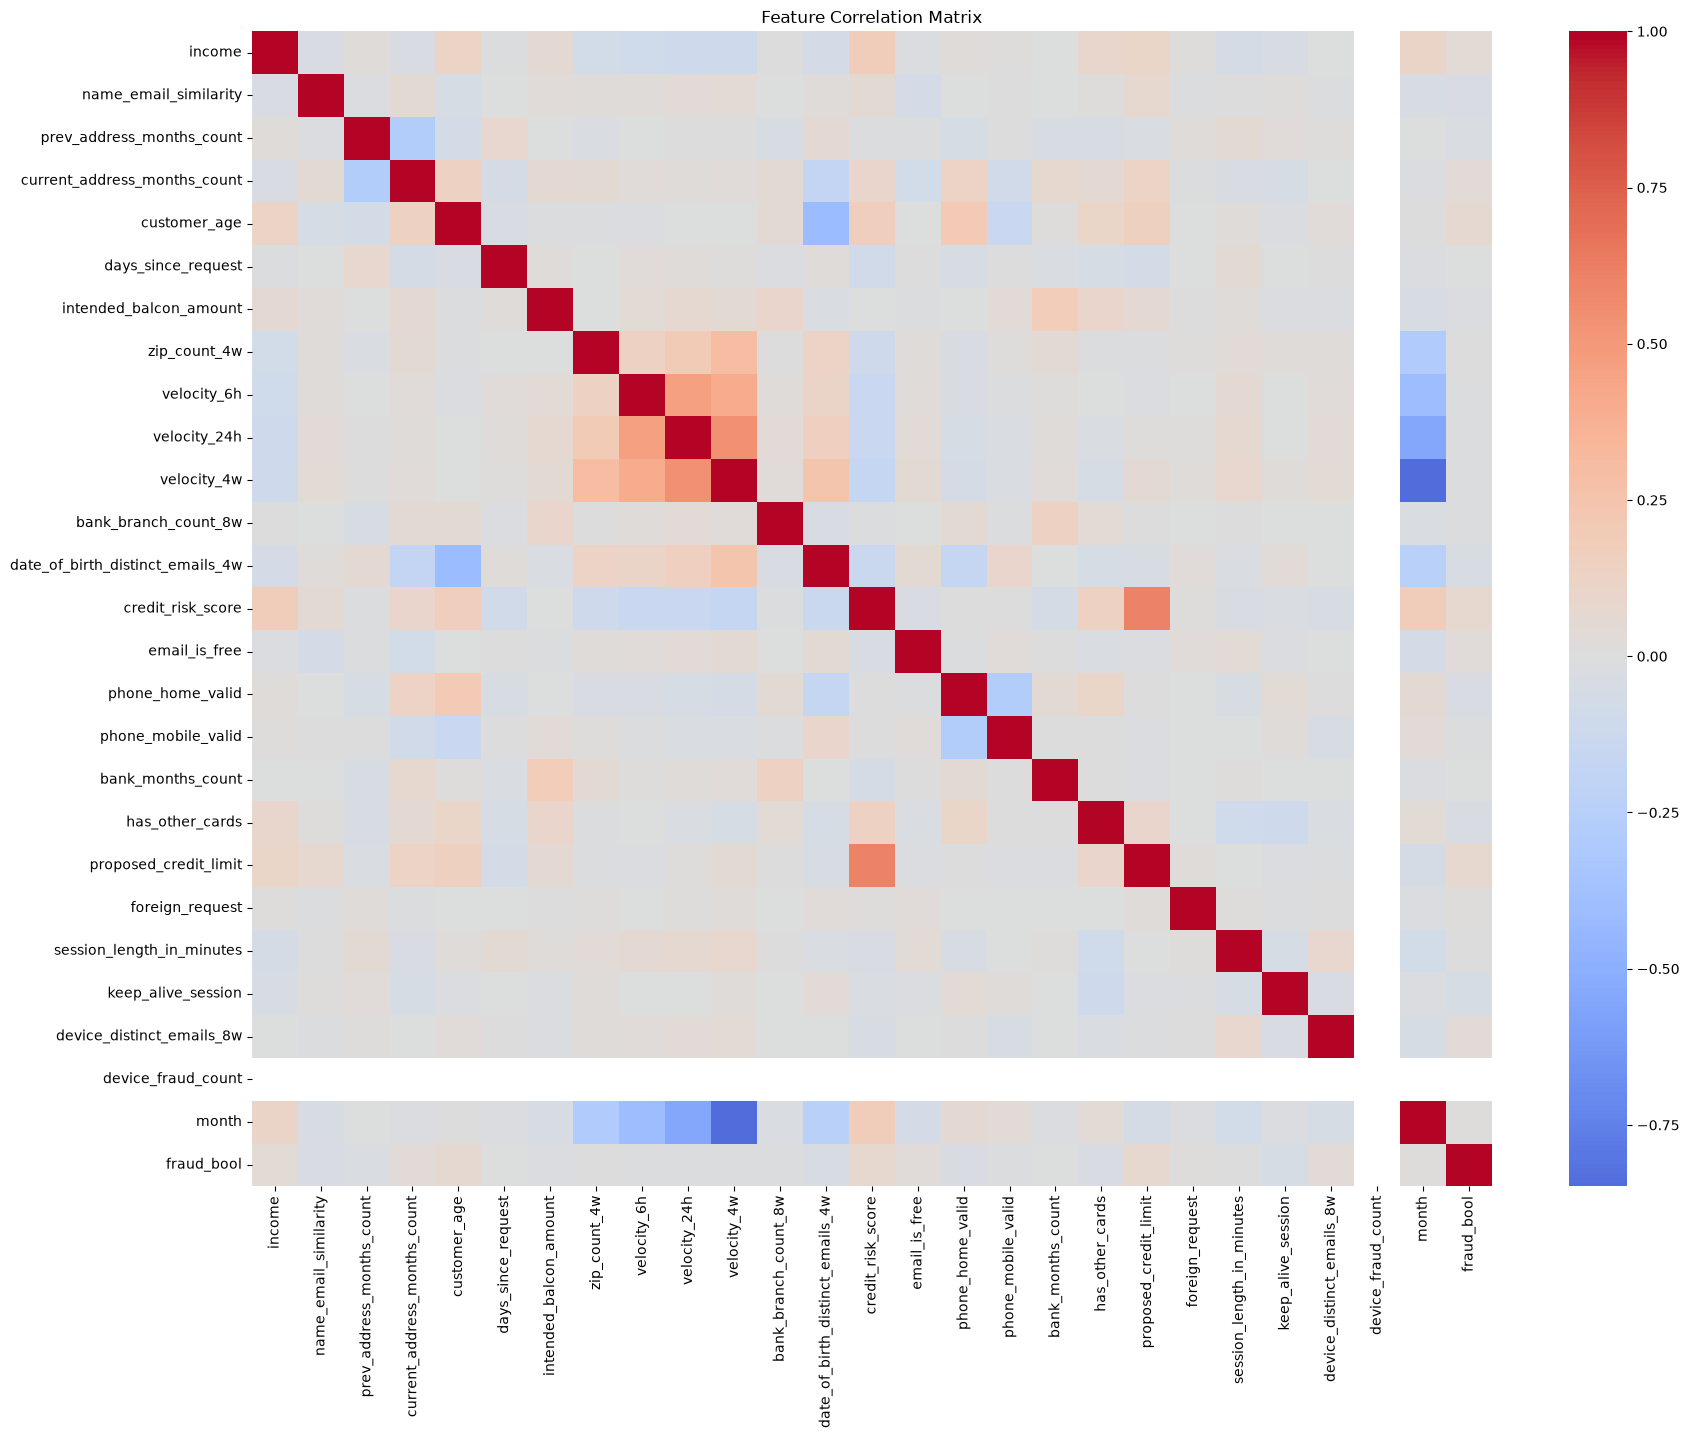

In [20]:
# correlation analysis
correlation_matrix = (
    df[numerical_features + ["fraud_bool"]]
    .corr()
)
fraud_corr = (
    correlation_matrix["fraud_bool"]
    .sort_values(ascending=False)
)

print(fraud_corr)
plt.figure(figsize=(8, 10))

fraud_corr.drop("fraud_bool").plot(
    kind="barh"
)

plt.title(
    "Feature Correlation with Fraud"
)

plt.xlabel("Correlation")

plt.show()
plt.figure(figsize=(20, 15))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

In [21]:
for col in numerical_features:

    negative_count = (
        df[col] < 0
    ).sum()

    if negative_count > 0:

        print(
            f"{col}: "
            f"{negative_count:,} negative values"
        )

for col in numerical_features:

    if (df[col] < 0).any():

        print(f"\n{col}")

        print(
            df[col]
            .value_counts()
            .sort_index()
            .head(10)
        )

prev_address_months_count: 712,920 negative values
current_address_months_count: 4,254 negative values
intended_balcon_amount: 742,523 negative values
velocity_6h: 44 negative values
credit_risk_score: 14,445 negative values
bank_months_count: 253,635 negative values
session_length_in_minutes: 2,015 negative values
device_distinct_emails_8w: 359 negative values

prev_address_months_count
prev_address_months_count
-1     712920
 5          1
 6         53
 7        409
 8       1962
 9       5558
 10     10082
 11     11475
 12      8712
 13      4448
Name: count, dtype: int64

current_address_months_count
current_address_months_count
-1     4254
 0     9609
 1    11297
 2    12741
 3    13986
 4    15030
 5    15896
 6    16376
 7    16270
 8    16089
Name: count, dtype: int64

intended_balcon_amount
intended_balcon_amount
-15.530555    1
-15.387590    1
-15.167388    1
-14.555656    1
-14.383932    1
-14.292259    1
-14.064980    1
-13.901393    1
-13.705594    1
-13.202786    1
Name:

In [22]:
# outlier analysis
outlier_summary = {}

for col in numerical_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()

    outlier_summary[col] = {
        "outliers": outliers,
        "percentage": (
            outliers / len(df)
        ) * 100
    }

outlier_df = pd.DataFrame(
    outlier_summary
).T

outlier_df = outlier_df.sort_values(
    "percentage",
    ascending=False
)

display(outlier_df)

,outliers,percentage
proposed_credit_limit,241742.0,24.1742
has_other_cards,222988.0,22.2988
intended_balcon_amount,222702.0,22.2702
bank_branch_count_8w,175243.0,17.5243
prev_address_months_count,157320.0,15.7320
phone_mobile_valid,110324.0,11.0324
days_since_request,94834.0,9.4834
session_length_in_minutes,78789.0,7.8789
zip_count_4w,59871.0,5.9871
current_address_months_count,41001.0,4.1001


In [23]:
duplicate_count = df.duplicated().sum()

print(
    f"Duplicate rows: {duplicate_count:,}"
)

print(
    f"Duplicate percentage: "
    f"{duplicate_count / len(df) * 100:.4f}%"
)

Duplicate rows: 0
Duplicate percentage: 0.0000%


In [25]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Samples",
        "Total Features",
        "Numerical Features",
        "Categorical Features",
        "Missing Values",
        "Duplicate Rows",
        "Fraud Cases",
        "Non-Fraud Cases",
        "Fraud Percentage",
        "Age Range",
        "Time Period Range"
    ],

    "Value": [
        len(df),
        df.shape[1] - 1,
        len(numerical_features),
        len(categorical_cols),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df.fraud_bool == 1).sum(),
        (df.fraud_bool == 0).sum(),
        round(df.fraud_bool.mean() * 100, 3),
        f"{df.customer_age.min()} - {df.customer_age.max()}",
        f"{df.month.min()} - {df.month.max()}"
    ]
})

display(eda_summary)
eda_summary.to_csv(
    "eda_summary.csv",
    index=False
)

,Metric,Value
0,Total Samples,1000000
1,Total Features,32
2,Numerical Features,26
3,Categorical Features,5
4,Missing Values,0
5,Duplicate Rows,0
6,Fraud Cases,11029
7,Non-Fraud Cases,988971
8,Fraud Percentage,1.103
9,Age Range,10 - 90


In [27]:
total_columns = df.shape[1]
predictive_features = df.shape[1] - 1

print("Total columns:", total_columns)
print("Predictive features:", predictive_features)

Total columns: 33
Predictive features: 32


In [28]:
fairness_groups = df["age_group"].copy()

X = df.drop(
    columns=["fraud_bool", "age_group"]
)

y = df["fraud_bool"]

In [ ]:
df["device_fraud_count"].value_counts()
print(df["device_fraud_count"].nunique())
print(df["device_fraud_count"].value_counts())

1


In [30]:
print(df["device_fraud_count"].value_counts())

device_fraud_count
0    1000000
Name: count, dtype: int64


In [33]:

print(df.shape)

(1000000, 32)


In [34]:
constant_cols = [
    col for col in df.columns
    if df[col].nunique() <= 1
]

print("Constant columns:", constant_cols)

Constant columns: []


In [36]:
# Make a copy first
df_cleaned = df.copy()

# Drop constant columns automatically
constant_cols = [
    col for col in df_cleaned.columns
    if df_cleaned[col].nunique() <= 1
]

print("Dropping:", constant_cols)

df_cleaned = df_cleaned.drop(columns=constant_cols)

print("New shape:", df_cleaned.shape)

Dropping: []
New shape: (1000000, 32)


In [37]:
import os


df_cleaned.to_csv(
    "../data/dataset.csv",
    index=False
)